## Data Verifications on STELA Sources



In [2]:
import platform
from dataclasses import dataclass

import numpy as np
from lexical_benchmark import settings
from lexical_benchmark.datasets import stella
from lexical_benchmark.utils import timed_status

assert platform.node() in settings.PATH.KNOWN_HOSTS, "Not in a known device, must provide custom PATH locations"

dataset = stella.STELATranscriptDataset()


@dataclass
class INFO:
    min: int
    max: int
    counts: list[int]

    @property
    def average(self) -> float:
        return float(np.average(self.counts))

    @property
    def sums(self) -> int:
        return int(np.sum(self.counts))


!date

Thu Nov 28 11:50:29 AM CET 2024


### STELA/EN/preprocessed-text

In [34]:
lang = "EN"
global_processed_stats = {}
with timed_status(status="Computing section sizes", complete_status="finished computing section sizes"):
    for hour in dataset.hour_splits:
        hour_stats = INFO(min=float("inf"), max=0, counts=[])
        for item in dataset.iter_split(lang, hour):
            words = item.preprocess.processed.read_tokenized()
            word_len = len(words)
            hour_stats.min = min(word_len, hour_stats.min)
            hour_stats.max = max(word_len, hour_stats.max)
            hour_stats.counts.append(word_len)
        global_processed_stats[hour] = hour_stats
!date

Output()

finished computing section sizes (Total time: 1 minute and 1 seconds)

### STELA/EN/cleaned-text

In [35]:
lang = "EN"
global_clean_stats = {}
with timed_status(status="Computing section sizes", complete_status="finished computing section sizes"):
    for hour in dataset.hour_splits:
        hour_stats = INFO(min=float("inf"), max=0, counts=[])
        for item in dataset.iter_split(lang, hour):
            words = item.clean.transcription.read_tokenized()
            word_len = len(words)
            hour_stats.min = min(word_len, hour_stats.min)
            hour_stats.max = max(word_len, hour_stats.max)
            hour_stats.counts.append(word_len)
        global_clean_stats[hour] = hour_stats
!date

finished computing section sizes (Total time: 57 seconds)

In [36]:
# Save cache data
stela_token_count_cache = {"global_clean_stats": global_clean_stats, "global_processed_stats": global_processed_stats}
%store stela_token_count_cache
!date

Stored 'stela_token_count_cache' (dict)

In [3]:
import matplotlib.pyplot as plt

%matplotlib widget


def format_big_numbers(num: int, abreviate: bool = True) -> str:
    """Abbreviate large numbers."""
    if not abreviate:
        return f"{int(num):,}"

    if num >= 1_000_000:
        return f"{num / 1_000_000:.2f}M"
    if num >= 1_000:
        return f"{num / 1_000:.2f}K"
    return f"{num:.1f}"


def plot_multiple_section_stats(
    dict1: dict[str, INFO], dict2: dict[str, INFO], titles: tuple[str, str, str] = ("Dataset 1", "Dataset 2", "Dataset 3"), abreviate_label: bool = True
) -> plt.Figure:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

    for ax, data, title in zip(axes, [dict1, dict2], titles, strict=False):
        # Prepare data extraction
        sections = list(data.keys())
        mins = [data[section].min for section in sections]
        maxs = [data[section].max for section in sections]
        averages = [data[section].average for section in sections]

        # Bar positions
        x = np.arange(len(sections))
        width = 0.25

        # Plot bars
        min_bars = ax.bar(x - width, mins, width, label="Minimum", color="blue", alpha=0.7)
        avg_bars = ax.bar(x, averages, width, label="Average", color="green", alpha=0.7)
        max_bars = ax.bar(x + width, maxs, width, label="Maximum", color="red", alpha=0.7)

        # Customize plot
        ax.set_xlabel("Sections", fontsize=12)
        ax.set_title(title, fontsize=14)
        ax.set_xticks(x)
        ax.set_xticklabels(sections, rotation=45, ha="right")

        # Add abbreviated value labels on top of each bar
        def add_value_labels(bars, offset: float = 0.0):
            for bar in bars:
                height = bar.get_height()
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    height + offset * height,  # Add a small offset for spacing
                    format_big_numbers(height, abreviate=abreviate_label),
                    ha="center",
                    va="bottom",
                    fontsize=9,
                    rotation=90,
                )

        add_value_labels(min_bars)
        add_value_labels(avg_bars)
        add_value_labels(max_bars)

    # Set common y-axis label and limits
    axes[0].set_ylabel("Count", fontsize=12)
    y_ticks = [min(data[section].min for section in dict1), max(data[section].max for section in dict1)]
    axes[0].set_ylim(0, max(y_ticks) * 1.1)

    # Add legend to the first subplot only
    axes[0].legend()

    # Add grid for better readability
    for ax in axes:
        ax.grid(axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout()
    # fig.suptitle('Section Statistics Across Datasets', fontsize=16)
    return fig


def plot_sums_of_sections(
    dict1: dict[str, INFO], dict2: dict[str, INFO], titles: tuple[str, str, str] = ("Dataset 1", "Dataset 2", "Dataset 3"), abreviate_label: bool = True
) -> plt.Figure:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

    for ax, data, title in zip(axes, [dict1, dict2], titles, strict=False):
        # Prepare data extraction
        sections = list(data.keys())
        sums = [data[section].sums for section in sections]

        # Plot the line plot of sums
        ax.plot(sections, sums, label="Sum", marker="o", color="purple", linestyle="-", linewidth=2)

        # Customize plot
        ax.set_xlabel("Sections", fontsize=12)
        ax.set_ylabel("Sum", fontsize=12)
        ax.set_title(title, fontsize=14)
        # Set x-ticks positions (already defined by 'x')
        ax.set_xticks(np.arange(len(sections)))
        ax.set_xticklabels(sections, rotation=45, ha="right")

        # Add values on top of each point (optional)
        for i, value in enumerate(sums):
            ax.text(sections[i], value, format_big_numbers(value, abreviate=abreviate_label), ha="center", va="bottom", fontsize=9, rotation=90)

    # Set common y-axis label and limits
    axes[0].set_ylabel("Sum", fontsize=12)

    # Add legend to the first subplot only
    axes[0].legend()

    # Add grid for better readability
    for ax in axes:
        ax.grid(axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout()
    return fig


!date

Thu Nov 28 11:50:39 AM CET 2024


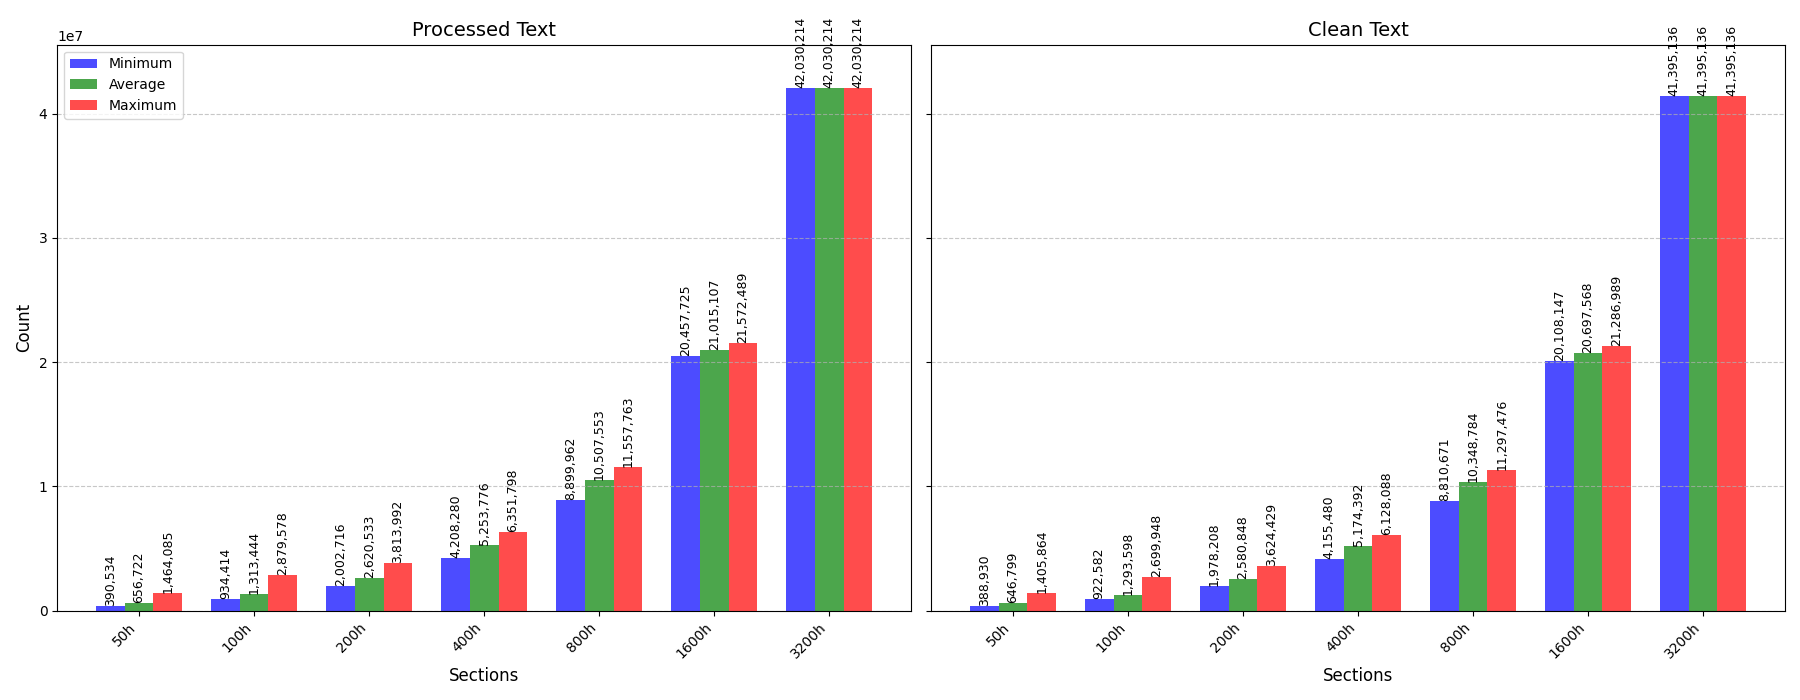

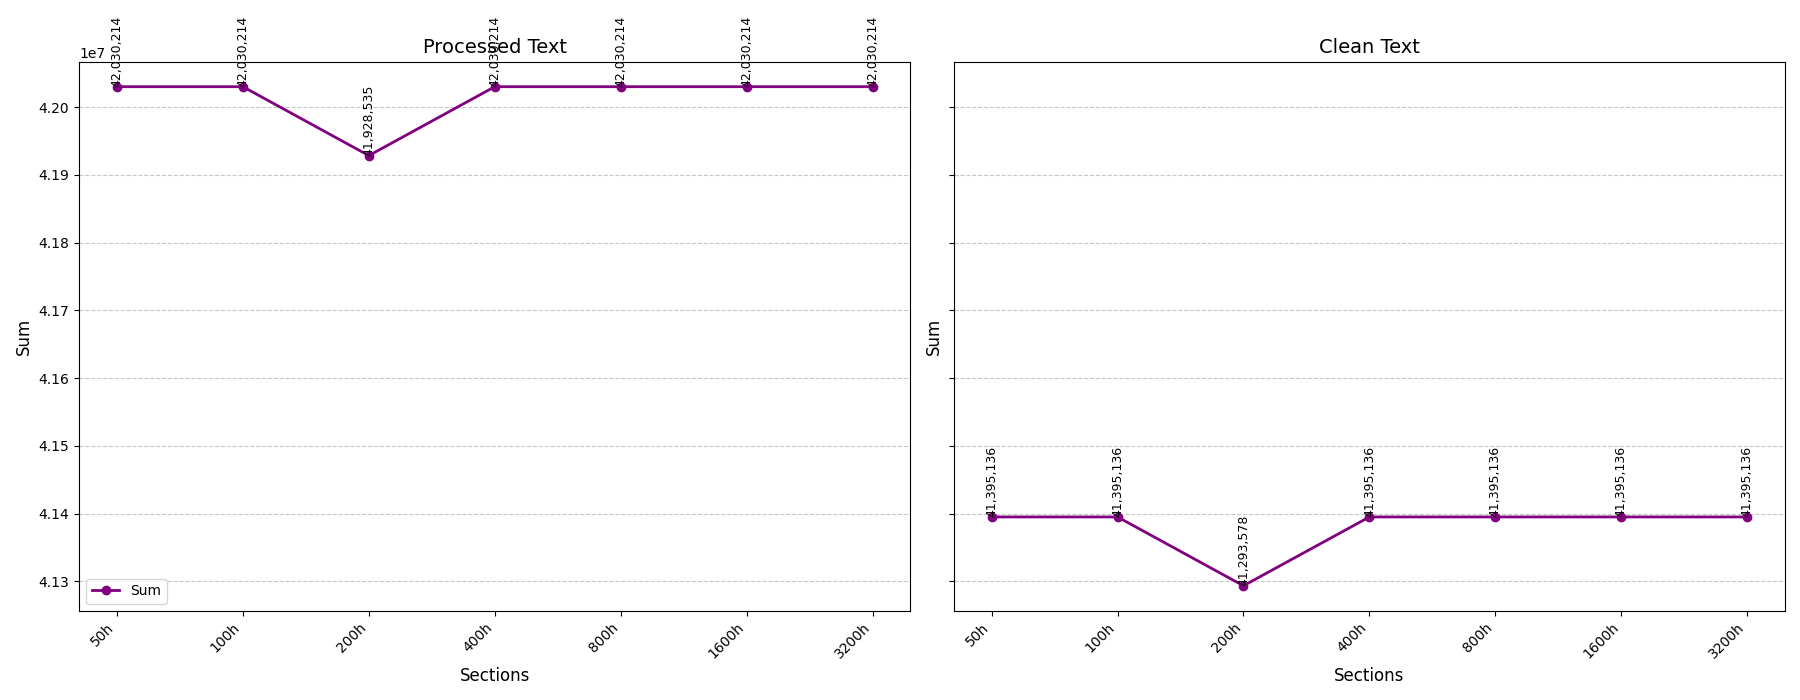

In [4]:
# Load from cache if variable not set
%store -r stela_token_count_cache
global_clean_stats = stela_token_count_cache["global_clean_stats"]
global_processed_stats = stela_token_count_cache["global_processed_stats"]


plt.close("all")  # Close previous figures
# Create plot
fig2 = plot_sums_of_sections(dict1=global_processed_stats, dict2=global_clean_stats, titles=("Processed Text", "Clean Text"), abreviate_label=False)
fig = plot_multiple_section_stats(dict1=global_processed_stats, dict2=global_clean_stats, titles=("Processed Text", "Clean Text"), abreviate_label=False)

plt.show()

## By Book Statistics

In [12]:
import functools
import platform

import pandas as pd
from lexical_benchmark import settings
from lexical_benchmark.datasets import stella
from lexical_benchmark.datasets import utils as dataset_utils
from lexical_benchmark.stats import block_average2
from lexical_benchmark.utils import timed_status

assert platform.node() in settings.PATH.KNOWN_HOSTS, "Not in a known device, must provide custom PATH locations"


dataset = stella.STELATranscriptDataset()
clean_rules = dataset.clean_up_rules("EN")
en_dict = dataset_utils.DictionairyCleaner(lang="EN")
loading_status = "Parsing book text & extracting stats"
complete_status = "Completed parsing & extraction of all books !!"


def word_clean_fn(word: str, word_dict) -> bool:
    """Check if a word is in dict"""
    return word_dict.check(word)


word_clean_en = functools.partial(word_clean_fn, word_dict=en_dict)


def tokenize(txt: list[str]) -> list[str]:
    """Split Lines of text into list of words."""
    words = []
    for line in txt:
        words.extend(line.split())
    return words


with timed_status(status=loading_status, complete_status=complete_status):
    # Fetch book index
    all_book_index = dataset.get_books(lang="EN").books
    book_clean_stats = {}
    for book_id, book_file in all_book_index.items():
        # Remove non-word items from text
        clean_txt = dataset_utils.DatasetCleaner.clean_txt(txt_dirty=book_file.safe_readlines(), ruleset=clean_rules)
        words = tokenize(clean_txt)
        # Perform word cleaning (keeping only stats)
        res = block_average2.word_clean_chunk(chunk=words, filter_fn=word_clean_en)
        book_clean_stats[book_id] = res
!date

Output()

Completed parsing & extraction of all books !! (Total time: 15 minutes and 8 seconds)

In [28]:
from IPython.display import HTML, display, display_html

rj_rate = [
    {
        "book": label,
        "Token Rejection Rate": cs.rejected_count / cs.total_words,
        "Type Rejection Rate": cs.chunk_unique_rejection_rate(),
        "Total Tokens": cs.total_words,
    }
    for label, cs in book_clean_stats.items()
]
book_df = pd.DataFrame(rj_rate)
sorted_books_df = book_df.sort_values("Type Rejection Rate")
display(sorted_books_df.style.format({"Token Rejection Rate": "{:.3%}", "Type Rejection Rate": "{:.3%}", "Total Tokens": lambda x: f"{int(x):,}"}))
!date

,book,Token Rejection Rate,Type Rejection Rate,Total Tokens
65,2638_LibriVox_en,0.000%,0.000%,"1,542"
348,767_LibriVox_en,0.000%,0.000%,"19,190"
196,6051_LibriVox_en,0.000%,0.000%,"16,010"
337,8082_LibriVox_en,0.000%,0.000%,"19,190"
316,7764_LibriVox_en,0.000%,0.000%,"20,707"
618,4251_LibriVox_en,0.000%,0.000%,"7,635"
355,2672_LibriVox_en,0.004%,0.036%,"24,484"
278,7261_LibriVox_en,0.013%,0.040%,"15,987"
325,5799_LibriVox_en,0.023%,0.070%,"48,192"
252,914_LibriVox_en,0.039%,0.082%,"15,560"


In [27]:
custom_book_df = book_df[book_df["Token Rejection Rate"] > 0.1]
display_html(HTML("<h3>Token Rejection >10%"))
display(custom_book_df.style.format({"Token Rejection Rate": "{:.3%}", "Type Rejection Rate": "{:.3%}", "Total Tokens": lambda x: f"{int(x):,}"}))
custom_book_df2 = book_df[book_df["Type Rejection Rate"] > 0.1]
display_html(HTML("<h3>Type Rejection >10%"))
display(custom_book_df2.style.format({"Token Rejection Rate": "{:.3%}", "Type Rejection Rate": "{:.3%}", "Total Tokens": lambda x: f"{int(x):,}"}))

Token Rejection >10%

,book,Token Rejection Rate,Type Rejection Rate,Total Tokens
224,5726_LibriVox_en,13.725%,76.779%,"486,199"
369,6910_LibriVox_en,11.687%,44.816%,"52,561"
370,4262_LibriVox_en,11.224%,68.958%,"149,495"
408,4955_LibriVox_en,17.792%,43.460%,"11,972"
619,5788_LibriVox_en,23.062%,78.425%,"706,567"


Type Rejection >10%

,book,Token Rejection Rate,Type Rejection Rate,Total Tokens
35,5674_LibriVox_en,2.621%,12.043%,"29,793"
58,8448_LibriVox_en,1.270%,11.990%,"80,896"
69,7291_LibriVox_en,3.221%,12.732%,"8,600"
79,8599_LibriVox_en,2.747%,15.738%,"34,182"
101,5261_LibriVox_en,1.283%,10.262%,"83,634"
142,3421_LibriVox_en,1.504%,13.635%,"86,741"
151,4689_LibriVox_en,1.781%,20.095%,"711,828"
152,7623_LibriVox_en,2.461%,15.018%,"115,930"
175,2287_LibriVox_en,5.149%,23.900%,"181,641"
180,6453_LibriVox_en,1.874%,10.712%,"53,106"


In [30]:
from pathlib import Path

import pandas as pd

MD_DIR = Path("../../data-v2/datasets/STELATranscriptions/metadata/")
duration_df = pd.read_csv(MD_DIR / "stela_audio_duration.csv", sep=";")
book_names = list(set(duration_df["book"].values.tolist()))
duration_df.head()

,lang,hour,split,section,book,wav,duration
0,EN,100h,0,1121,1812_LibriVox_en,1812_LibriVox_en_seq_08.wav,272.734
1,EN,100h,0,1121,1812_LibriVox_en,1812_LibriVox_en_seq_09.wav,71.899
2,EN,100h,0,1121,1812_LibriVox_en,1812_LibriVox_en_seq_10.wav,170.762
3,EN,100h,0,1121,1812_LibriVox_en,1812_LibriVox_en_seq_11.wav,49.589
4,EN,100h,0,1121,1812_LibriVox_en,1812_LibriVox_en_seq_12.wav,16.377


In [32]:
book_summary = duration_df[duration_df["hour"] == "3200h"]
books_3200h = list(set(book_summary["book"].values.tolist()))
print(f"{len(book_names)=} and {len(books_3200h)=} should be equal")
book_summary = (
    duration_df.groupby("book")
    .agg(
        {
            "lang": "first",
            "wav": "count",
            "duration": "sum",
        }
    )
    .rename(columns={"wav": "file_count"})
)
book_summary.to_csv(MD_DIR / "book_audio_durations.csv")
book_summary.head()

len(book_names)=651 and len(books_3200h)=651 should be equal


,lang,file_count,duration
book,,,
1050_LibriVox_en,EN,539,13552.938
1055_LibriVox_en,EN,1463,105944.867
1084_LibriVox_en,EN,812,7138.607
1087_LibriVox_en,EN,4165,100092.069
1096_LibriVox_en,EN,917,100464.105


In [50]:
book_summary = duration_df.groupby(["lang", "hour", "split", "section", "book"]).agg({"duration": "sum", "wav": "count"}).rename(columns={"wav": "file_count"}).reset_index()


book_summary2 = (
    book_summary.groupby(["lang", "hour", "split", "section"]).agg({"duration": "sum", "file_count": "sum", "book": "count"}).rename(columns={"book": "book_count"}).reset_index()
)


stela_duration_detailed = (
    book_summary2.groupby(["lang", "hour", "split"])
    .agg({"duration": "sum", "file_count": "sum", "book_count": "sum", "section": "count"})
    .rename(columns={"section": "section_count"})
    .reset_index()
)


stela_duration_detailed.to_csv(MD_DIR / "audio_durations.csv", sep=";", index=False)
stela_duration_detailed.head()

,lang,hour,split,duration,file_count,book_count,section_count
0,EN,100h,0,346697.649,12183,20,20
1,EN,100h,1,356962.340,6578,17,14
2,EN,100h,2,352483.186,7514,16,14
3,EN,100h,3,350429.510,9058,20,16
4,EN,100h,4,324628.678,6138,21,14


In [53]:
import humanize

stela_duration = (
    stela_duration_detailed.groupby(["lang", "hour"])
    .agg({"duration": "sum", "file_count": "sum", "book_count": "sum", "section_count": "sum", "split": "count"})
    .rename(columns={"split": "split_count"})
    .reset_index()
)
stela_duration.style.format({"duration": lambda x: humanize.precisedelta(x)})

,lang,hour,duration,file_count,book_count,section_count,split_count
0,EN,100h,"4 months, 10 days, 17 hours, 11 minutes and 33 seconds",309160,651,553,32
1,EN,1600h,"4 months, 10 days, 17 hours, 11 minutes and 33 seconds",309160,651,217,2
2,EN,200h,"4 months, 10 days, 9 hours, 4 minutes and 36 seconds",308028,650,473,16
3,EN,3200h,"4 months, 10 days, 17 hours, 11 minutes and 33 seconds",309160,651,147,1
4,EN,400h,"4 months, 10 days, 17 hours, 11 minutes and 33 seconds",309160,651,393,8
5,EN,50h,"4 months, 10 days, 17 hours, 11 minutes and 33 seconds",309160,651,621,64
6,EN,800h,"4 months, 10 days, 17 hours, 11 minutes and 33 seconds",309160,651,299,4
